# Process Discovery

In [ ]:
!pip uninstall -y networkx
!pip install networkx==2.6.3

Found existing installation: networkx 3.6.1
Uninstalling networkx-3.6.1:
  Successfully uninstalled networkx-3.6.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 23.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
spopt 0.7.0 requires networkx>=3.2, but you have networkx 2.6.3 which is incompatible.
mapclassify 2.10.0 requires networkx>=3.2, but you have networkx 2.6.3 which is incompatible.
momepy 0.11.0 requires networkx>=3.2, but you have networkx 2.6.3 which is incompatible.
scikit-image 0.25.2 requires networkx>=3.0, but you have networkx 2.6.3 which is incompatible.


## Install Pm4py

In [ ]:
!pip install pm4py==2.7.19.4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 78.0 MB/s eta 0:00:00


In [ ]:
import pm4py
print(pm4py.__version__)

2.7.19.4


## Import File

In [ ]:
# from google.colab import files
from pm4py.objects.log.importer.xes import importer as xes_importer
from pm4py.objects.conversion.log import converter as log_converter

# Fungsi Bantuan

## evaluate_model_quality

In [ ]:
from pm4py.algo.evaluation.replay_fitness import algorithm as fitness_evaluator
from pm4py.algo.evaluation.precision import algorithm as precision_evaluator
from pm4py.algo.evaluation.generalization import algorithm as generalization_evaluator
from pm4py.algo.evaluation.simplicity import algorithm as simplicity_evaluator
from pm4py.algo.analysis.woflan import algorithm as woflan # Import woflan for soundness evaluation

def evaluate_model_quality(event_log, net, initial_marking, final_marking):
    """
    Evaluates the quality of a process model (Petri net) against an event log.

    Args:
        event_log: The event log (pm4py.objects.log.obj.EventLog).
        net: The Petri net (pm4py.objects.petri.petrinet.PetriNet).
        initial_marking: The initial marking of the Petri net.
        final_marking: The final marking of the Petri net.

    Returns:
        dict: A dictionary containing fitness, precision, generalization, simplicity, and soundness scores.
    """

    fitness = fitness_evaluator.apply(event_log, net, initial_marking, final_marking)
    precision = precision_evaluator.apply(event_log, net, initial_marking, final_marking)
    generalization = generalization_evaluator.apply(event_log, net, initial_marking, final_marking)
    simplicity = simplicity_evaluator.apply(net)
    soundness = woflan.apply(net, initial_marking, final_marking) # Evaluate soundness

    print("=== Model Evaluation ===")
    print(f"Fitness       : {fitness['log_fitness']:.4f}")
    print(f"Precision     : {precision:.4f}")
    print(f"Generalization: {generalization:.4f}")
    print(f"Simplicity    : {simplicity:.4f}")
    print(f"Soundness     : {soundness}") # Print soundness result

    return {
        'fitness': fitness['log_fitness'],
        'precision': precision,
        'generalization': generalization,
        'simplicity': simplicity,
        'soundness': soundness # Add soundness to the returned dictionary
    }

# You can call this function later with your desired log and model
# For example, after discovering a model like net_im, initial_marking_im, final_marking_im


## calculate_mean_case_duration

In [ ]:
import statistics
from pm4py.statistics.traces.generic.log import case_statistics

def calculate_mean_case_duration(event_log):
    """
    Calculates the mean case duration from an event log.

    Args:
        event_log: The PM4Py event log object.

    Returns:
        A string representing the mean case duration in days, hours, minutes, and seconds.
        Returns an error message if no cases are found.
    """
    durations_in_seconds = case_statistics.get_all_case_durations(event_log)

    if durations_in_seconds:
        mean_duration_seconds = statistics.mean(durations_in_seconds)

        days = int(mean_duration_seconds // (24 * 3600))
        mean_duration_seconds %= (24 * 3600)
        hours = int(mean_duration_seconds // 3600)
        mean_duration_seconds %= 3600
        minutes = int(mean_duration_seconds // 60)
        seconds = int(mean_duration_seconds % 60)

        return f"{days} days, {hours} hours, {minutes} minutes, {seconds} seconds"
    else:
        return "No cases found to calculate mean duration."


## calculate_dwelling_time_per_case

In [ ]:
from datetime import datetime

def calculate_dwelling_time_per_case(event_log, start_activity='DISCHARGE', end_activity='TRUCK_OUT'):
    """
    Calculates the dwelling time for each case between a specific start and end activity.

    Args:
        event_log: The PM4Py event log object.
        start_activity (str): The name of the starting activity.
        end_activity (str): The name of the ending activity.

    Returns:
        A dictionary where keys are case IDs and values are the dwelling times in seconds.
    """
    dwelling_times_per_case = {}

    for trace in event_log:
        case_id = trace.attributes.get('concept:name', 'Unknown_Case')
        discharge_time = None
        truck_out_time = None

        for event in trace:
            activity_name = event['concept:name']
            timestamp = event['time:timestamp']

            if activity_name == start_activity:
                discharge_time = timestamp
            elif activity_name == end_activity and discharge_time is not None:
                truck_out_time = timestamp
                break

        if discharge_time is not None and truck_out_time is not None:
            duration = (truck_out_time - discharge_time).total_seconds()
            dwelling_times_per_case[case_id] = duration

    return dwelling_times_per_case

## filter_log_by_case_id

In [ ]:
from pm4py.objects.log.obj import EventLog

def filter_log_by_case_ids(event_log, case_ids_to_retain):
    """
    Filters an event log to retain only traces whose case IDs are in the provided list.

    Args:
        event_log (pm4py.objects.log.obj.EventLog): The input event log.
        case_ids_to_retain (list): A list of case IDs (strings) to retain.

    Returns:
        pm4py.objects.log.obj.EventLog: A new event log containing only the filtered traces.
    """
    filtered_log = EventLog()
    case_ids_to_retain_set = set(case_ids_to_retain) # Convert to set for faster lookup

    for trace in event_log:
        case_id = trace.attributes.get('concept:name')
        if case_id in case_ids_to_retain_set:
            filtered_log.append(trace)

    return filtered_log

## Inductive Miner complete

In [ ]:
from pm4py.algo.discovery.inductive import algorithm as inductive_miner
from pm4py.objects.conversion.process_tree import converter as pt_converter
from pm4py.visualization.petri_net import visualizer as pn_vis

def perform_inductive_miner_with_eval_and_viz(event_log, noise_threshold=0.0):
    """
    Performs Inductive Miner process discovery, converts the process tree to a Petri net,
    evaluates the model's quality, and visualizes the Petri net.

    Args:
        event_log: The event log (pm4py.objects.log.obj.EventLog).
        noise_threshold (float): The noise threshold for the Inductive Miner algorithm.

    Returns:
        tuple: A tuple containing the discovered Petri net (net, initial_marking, final_marking).
    """
    print(f"\n--- Discovering model with Inductive Miner (noiseThreshold={noise_threshold}) ---")
    process_tree = inductive_miner.apply(
        event_log,
        variant=inductive_miner.Variants.IM,
        parameters={'noiseThreshold': noise_threshold}
    )

    net_im, initial_marking_im, final_marking_im = pt_converter.apply(process_tree)

    # print("--- Evaluating Inductive Miner Model ---")
    # evaluate_model_quality(event_log, net_im, initial_marking_im, final_marking_im)

    # Visualize the discovered Petri net, passing the original event_log for performance context
    gviz_im = pn_vis.apply(
        net_im,
        initial_marking_im,
        final_marking_im,
        log=event_log, # Use the original event_log for performance context in visualization
        variant=pn_vis.Variants.PERFORMANCE
    )
    pn_vis.view(gviz_im)
    print("Petri net visualization displayed.")

    return net_im, initial_marking_im, final_marking_im

print("Function 'perform_inductive_miner_and_evaluate' defined.")

Function 'perform_inductive_miner_and_evaluate' defined.


## Heuristic Miner complete

In [ ]:
from pm4py.algo.discovery.heuristics import algorithm as heuristic_miner
from pm4py.visualization.petri_net import visualizer as pn_vis

def perform_heuristic_miner_with_eval_and_viz(event_log, dependency_threshold=0.2):
    """
    Performs Heuristic Miner process discovery, evaluates the model's quality,
    and visualizes the Petri net.

    Args:
        event_log: The event log (pm4py.objects.log.obj.EventLog).
        dependency_threshold (float): The dependency threshold for the Heuristic Miner algorithm.

    Returns:
        tuple: A tuple containing the discovered Petri net (net, initial_marking, final_marking).
    """
    print(f"\n--- Discovering model with Heuristic Miner (dependencyThreshold={dependency_threshold}) ---")

    parameters = {
        heuristic_miner.Variants.CLASSIC.value.Parameters.DEPENDENCY_THRESH: dependency_threshold
    }

    net_hm, initial_marking_hm, final_marking_hm = heuristic_miner.apply(event_log, parameters=parameters)

    # print("--- Evaluating Heuristic Miner Model ---")
    # evaluate_model_quality(event_log, net_hm, initial_marking_hm, final_marking_hm)

    # Visualize the discovered Petri net, passing the original event_log for performance context
    gviz_hm = pn_vis.apply(
        net_hm,
        initial_marking_hm,
        final_marking_hm,
        log=event_log, # Use the original event_log for performance context in visualization
        variant=pn_vis.Variants.PERFORMANCE
    )
    pn_vis.view(gviz_hm)
    print("Petri net visualization displayed.")

    return net_hm, initial_marking_hm, final_marking_hm

print("Function 'perform_heuristic_miner_with_eval_and_viz' defined.")

Function 'perform_heuristic_miner_with_eval_and_viz' defined.


## Alpha Miner complete

In [ ]:
from pm4py.algo.discovery.alpha import algorithm as alpha_miner
from pm4py.visualization.petri_net import visualizer as pn_vis

def perform_alpha_miner_with_eval_and_viz(event_log):
    """
    Performs Alpha Miner process discovery, evaluates the model's quality,
    and visualizes the Petri net.

    Args:
        event_log: The event log (pm4py.objects.log.obj.EventLog).

    Returns:
        tuple: A tuple containing the discovered Petri net (net, initial_marking, final_marking).
    """
    print("\n--- Discovering model with Alpha Miner ---")

    net_am, initial_marking_am, final_marking_am = alpha_miner.apply(event_log)

    # print("--- Evaluating Alpha Miner Model ---")
    # evaluate_model_quality(event_log, net_am, initial_marking_am, final_marking_am)

    # Visualize the discovered Petri net, passing the original event_log for performance context
    gviz_am = pn_vis.apply(
        net_am,
        initial_marking_am,
        final_marking_am,
        log=event_log, # Use the original event_log for performance context in visualization
        variant=pn_vis.Variants.PERFORMANCE
    )
    pn_vis.view(gviz_am)
    print("Petri net visualization displayed.")

    return net_am, initial_marking_am, final_marking_am

print("Function 'perform_alpha_miner_with_eval_and_viz' defined.")

Function 'perform_alpha_miner_with_eval_and_viz' defined.


## Compare All Miner

In [ ]:
import pandas as pd

def compare_all_miners(event_log):
    print("\n--- Starting Comparison of Process Discovery Algorithms ---")

    results = []

    # Inductive Miner
    print("\n###########################################")
    print("\nProcessing Inductive Miner...")
    net_im, initial_marking_im, final_marking_im = perform_inductive_miner_with_eval_and_viz(event_log)
    im_metrics = evaluate_model_quality(event_log, net_im, initial_marking_im, final_marking_im)
    results.append({'Miner': 'Inductive Miner', **im_metrics})

    # Heuristic Miner
    print("\n###########################################")
    print("\nProcessing Heuristic Miner...")
    net_hm, initial_marking_hm, final_marking_hm = perform_heuristic_miner_with_eval_and_viz(event_log)
    # Explicitly collect metrics using the modified evaluate_model_quality function
    hm_metrics = evaluate_model_quality(event_log, net_hm, initial_marking_hm, final_marking_hm)
    results.append({'Miner': 'Heuristic Miner', **hm_metrics})

    # Alpha Miner
    print("\n###########################################")

    print("\nProcessing Alpha Miner...")
    net_am, initial_marking_am, final_marking_am = perform_alpha_miner_with_eval_and_viz(event_log)
    # Explicitly collect metrics using the modified evaluate_model_quality function
    am_metrics = evaluate_model_quality(event_log, net_am, initial_marking_am, final_marking_am)
    results.append({'Miner': 'Alpha Miner', **am_metrics})

    df_results = pd.DataFrame(results)
    print("\n--- Overall Process Discovery Comparison Results ---")
    print(df_results)
    return df_results, [net_im, initial_marking_im, final_marking_im], [net_hm, initial_marking_hm, final_marking_hm], [net_am, initial_marking_am, final_marking_am] # Optionally return the DataFrame

## Display pnml model

In [ ]:
def display_pnml_model(file_path, title):
    """
    Loads a PNML file and displays its Petri net visualization.

    Args:
        file_path (str): The path to the PNML file.
        title (str): A title for the displayed model.
    """
    print(f"\n--- Displaying model: {title} ---")
    try:
        net, initial_marking, final_marking = pm4py.read_pnml(file_path)
        gviz = pn_vis.apply(net, initial_marking, final_marking)
        pn_vis.view(gviz)
        print(f"Petri net from '{file_path}' displayed.")
    except Exception as e:
        print(f"Error displaying '{file_path}': {e}")

# Load Data

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
# Adjust the path to your XES file in Google Drive
log_path_gdrive = "/content/gdrive/MyDrive/Colab Notebooks/TPS/green_log_no_plp.xes (2).gz" # REPLACE WITH YOUR FILE PATH

try:
    event_log = xes_importer.apply(log_path_gdrive)
    print(f"Successfully loaded event log from Google Drive: {log_path_gdrive}")
    print(f"Number of traces: {len(event_log)}")
except Exception as e:
    print(f"Error loading log from Google Drive: {e}")
    print("Please ensure the file path is correct and your Google Drive is mounted properly.")

parsing log, completed traces ::   0%|          | 0/60029 [00:00<?, ?it/s]

Successfully loaded event log from Google Drive: /content/gdrive/MyDrive/Colab Notebooks/TPS/green_log_no_plp.xes (2).gz
Number of traces: 60029


# Data Understanding

In [ ]:
from pm4py.objects.conversion.log import converter as log_converter

df_converted = log_converter.apply(event_log, variant=log_converter.Variants.TO_DATA_FRAME)

In [ ]:
df_converted.head(5)

,lifecycle:transition,time:timestamp,concept:name,ACTIVITY,case:concept:name,case:variant,case:variant-index,case:creator,case:CONTAINER_KEY,case:CTR_SIZE,case:CTR_TYPE,case:GROSS,case:YARD_BLOCK,case:YARD_SLOT,case:JOB_DEL_DOCTYPE
0,complete,2021-09-26 14:12:10+00:00,DISCHARGE,DISCHARGE,AAMU2609009-2021-09-26,Variant 2,2,Fluxicon Disco,AAMU2609009,20,TNK,25.9,P,51.0,SPPB
1,complete,2021-09-26 14:33:37+00:00,STACK,STACK,AAMU2609009-2021-09-26,Variant 2,2,Fluxicon Disco,AAMU2609009,20,TNK,25.9,P,51.0,SPPB
2,complete,2021-09-28 00:00:00+00:00,CUSTOMS_DEL,CUSTOMS_DEL,AAMU2609009-2021-09-26,Variant 2,2,Fluxicon Disco,AAMU2609009,20,TNK,25.9,P,51.0,SPPB
3,complete,2021-09-28 15:07:04+00:00,JOB_DEL,JOB_DEL,AAMU2609009-2021-09-26,Variant 2,2,Fluxicon Disco,AAMU2609009,20,TNK,25.9,P,51.0,SPPB
4,complete,2021-09-29 21:04:03+00:00,TRUCK_IN,TRUCK_IN,AAMU2609009-2021-09-26,Variant 2,2,Fluxicon Disco,AAMU2609009,20,TNK,25.9,P,51.0,SPPB


In [ ]:
from pm4py.statistics.variants.log import get as variants_get

variants = variants_get.get_variants(event_log)

# Print some information about the variants
print(f"Total unique variants: {len(variants)}")

Total unique variants: 5


In [ ]:
dfg, start_activities, end_activities = pm4py.discover_dfg(event_log)
print("Start Activities:", start_activities)
print("End Activities:", end_activities)

Start Activities: {'DISCHARGE': 28724, 'CUSTOMS_DEL': 31305}
End Activities: {'TRUCK_OUT': 59939, 'CUSTOMS_DEL': 90}


In [ ]:
import statistics
from pm4py.statistics.traces.generic.log import case_statistics

print("Mean Case Duration:", calculate_mean_case_duration(event_log))

Mean Case Duration: 3 days, 10 hours, 17 minutes, 52 seconds


# Data Preparation

In [ ]:
from datetime import datetime

case_dwelling_times = calculate_dwelling_time_per_case(event_log, 'DISCHARGE', 'TRUCK_OUT')

if case_dwelling_times:
    total_dwelling_duration_seconds = sum(case_dwelling_times.values())
    mean_dwelling_time_seconds = total_dwelling_duration_seconds / len(case_dwelling_times)

    # Convert to readable format
    days = int(mean_dwelling_time_seconds // (24 * 3600))
    mean_dwelling_time_seconds %= (24 * 3600)
    hours = int(mean_dwelling_time_seconds // 3600)
    mean_dwelling_time_seconds %= 3600
    minutes = int(mean_dwelling_time_seconds // 60)
    seconds = int(mean_dwelling_time_seconds % 60)

    print(f"Rata-rata Dwelling Time (DISCHARGE ke TRUCK_OUT): {days} hari, {hours} jam, {minutes} menit, {seconds} detik")
else:
    print("Tidak ada kasus yang memiliki aktivitas 'DISCHARGE' diikuti oleh 'TRUCK_OUT'.")

Rata-rata Dwelling Time (DISCHARGE ke TRUCK_OUT): 2 hari, 18 jam, 34 menit, 45 detik


In [ ]:
if case_dwelling_times:
    longest_duration_case_id = None
    max_duration_seconds = -1

    for case_id, duration_seconds in case_dwelling_times.items():
        if duration_seconds > max_duration_seconds:
            max_duration_seconds = duration_seconds
            longest_duration_case_id = case_id

    # Convert to readable format
    days = int(max_duration_seconds // (24 * 3600))
    max_duration_seconds %= (24 * 3600)
    hours = int(max_duration_seconds // 3600)
    max_duration_seconds %= 3600
    minutes = int(max_duration_seconds // 60)
    seconds = int(max_duration_seconds % 60)

    print(f"Case dengan waktu dwelling time paling lama (DISCHARGE sampai TRUCK_OUT):")
    print(f"  Case ID: {longest_duration_case_id}")
    print(f"  Durasi: {days} hari, {hours} jam, {minutes} menit, {seconds} detik")
else:
    print("Tidak ada data dwelling time yang tersedia untuk dianalisis.")

Case dengan waktu dwelling time paling lama (DISCHARGE sampai TRUCK_OUT):
  Case ID: REGU3234839-2021-07-23
  Durasi: 60 hari, 0 jam, 21 menit, 2 detik


In [ ]:
if case_dwelling_times:
    three_days_in_seconds = 3 * 24 * 3600
    cases_within_three_days = 0

    for case_id, duration_seconds in case_dwelling_times.items():
        if duration_seconds <= three_days_in_seconds:
            cases_within_three_days += 1

    total_cases_with_dwelling_time = len(case_dwelling_times)
    percentage_within_three_days = (cases_within_three_days / total_cases_with_dwelling_time) * 100 if total_cases_with_dwelling_time > 0 else 0

    cases_more_than_three_days = total_cases_with_dwelling_time - cases_within_three_days
    percentage_more_than_three_days = (cases_more_than_three_days / total_cases_with_dwelling_time) * 100 if total_cases_with_dwelling_time > 0 else 0

    print(f"Jumlah kasus dengan dwelling time (DISCHARGE ke TRUCK_OUT) kurang dari atau sama dengan 3 hari: {cases_within_three_days} ({percentage_within_three_days:.2f}%)")
    print(f"Jumlah kasus dengan dwelling time (DISCHARGE ke TRUCK_OUT) lebih dari 3 hari: {cases_more_than_three_days} ({percentage_more_than_three_days:.2f}%)")
    print(f"Total kasus yang memiliki dwelling time antara DISCHARGE dan TRUCK_OUT: {total_cases_with_dwelling_time}")
else:
    print("Tidak ada data dwelling time yang tersedia untuk dianalisis.")

Jumlah kasus dengan dwelling time (DISCHARGE ke TRUCK_OUT) kurang dari atau sama dengan 3 hari: 39989 (66.62%)
Jumlah kasus dengan dwelling time (DISCHARGE ke TRUCK_OUT) lebih dari 3 hari: 20040 (33.38%)
Total kasus yang memiliki dwelling time antara DISCHARGE dan TRUCK_OUT: 60029


In [ ]:
three_days_in_seconds = 3 * 24 * 3600
cases_under_3_days_ids = []
cases_over_3_days_ids = []

for case_id, duration_seconds in case_dwelling_times.items():
    if duration_seconds <= three_days_in_seconds:
        cases_under_3_days_ids.append(case_id)
    else:
        cases_over_3_days_ids.append(case_id)

print(f"Number of case IDs with dwelling time <= 3 days: {len(cases_under_3_days_ids)}")
print(f"Number of case IDs with dwelling time > 3 days: {len(cases_over_3_days_ids)}")

Number of case IDs with dwelling time <= 3 days: 39989
Number of case IDs with dwelling time > 3 days: 20040


In [ ]:
log_under_3_days = filter_log_by_case_ids(event_log, cases_under_3_days_ids)
log_over_3_days = filter_log_by_case_ids(event_log, cases_over_3_days_ids)

print(f"Number of traces in log_under_3_days: {len(log_under_3_days)}")
print(f"Number of traces in log_over_3_days: {len(log_over_3_days)}")

Number of traces in log_under_3_days: 39989
Number of traces in log_over_3_days: 20040


In [ ]:
type(log_under_3_days)

pm4py.objects.log.obj.EventLog

## Variants Filtering

In [ ]:
from pm4py.statistics.variants.log import get as variants_get

variants_under_3_days = variants_get.get_variants(log_under_3_days)

print(f"Total unique variants in log_under_3_days: {len(variants_under_3_days)}\n")
print("Variants and their frequencies (for log_under_3_days):")
# Sort variants by frequency in descending order for better readability
sorted_variants = sorted(variants_under_3_days.items(), key=lambda item: len(item[1]), reverse=True)

for variant_tuple, traces in sorted_variants:
    variant_name = ' -> '.join(variant_tuple) # Convert tuple to a readable string
    frequency = len(traces)
    print(f"- Variant: {variant_name} (Frequency: {frequency})")

Total unique variants in log_under_3_days: 4

Variants and their frequencies (for log_under_3_days):
- Variant: CUSTOMS_DEL -> DISCHARGE -> STACK -> JOB_DEL -> TRUCK_IN -> UNSTACK_TO_TRUCK -> TRUCK_OUT (Frequency: 26568)
- Variant: DISCHARGE -> STACK -> CUSTOMS_DEL -> JOB_DEL -> TRUCK_IN -> UNSTACK_TO_TRUCK -> TRUCK_OUT (Frequency: 11745)
- Variant: CUSTOMS_DEL -> DISCHARGE -> JOB_DEL -> STACK -> TRUCK_IN -> UNSTACK_TO_TRUCK -> TRUCK_OUT (Frequency: 1361)
- Variant: DISCHARGE -> CUSTOMS_DEL -> STACK -> JOB_DEL -> TRUCK_IN -> UNSTACK_TO_TRUCK -> TRUCK_OUT (Frequency: 315)


In [ ]:
from pm4py.statistics.variants.log import get as variants_get

variants_over_3_days = variants_get.get_variants(log_over_3_days)

print(f"Total unique variants in log_over_3_days: {len(variants_over_3_days)}\n")
print("Variants and their frequencies (for log_over_3_days):")
# Sort variants by frequency in descending order for better readability
sorted_variants_over_3_days = sorted(variants_over_3_days.items(), key=lambda item: len(item[1]), reverse=True)

for variant_tuple, traces in sorted_variants_over_3_days:
    variant_name = ' -> '.join(variant_tuple) # Convert tuple to a readable string
    frequency = len(traces)
    print(f"- Variant: {variant_name} (Frequency: {frequency})")

Total unique variants in log_over_3_days: 5

Variants and their frequencies (for log_over_3_days):
- Variant: DISCHARGE -> STACK -> CUSTOMS_DEL -> JOB_DEL -> TRUCK_IN -> UNSTACK_TO_TRUCK -> TRUCK_OUT (Frequency: 16500)
- Variant: CUSTOMS_DEL -> DISCHARGE -> STACK -> JOB_DEL -> TRUCK_IN -> UNSTACK_TO_TRUCK -> TRUCK_OUT (Frequency: 3364)
- Variant: DISCHARGE -> STACK -> JOB_DEL -> TRUCK_IN -> UNSTACK_TO_TRUCK -> TRUCK_OUT -> CUSTOMS_DEL (Frequency: 90)
- Variant: DISCHARGE -> CUSTOMS_DEL -> STACK -> JOB_DEL -> TRUCK_IN -> UNSTACK_TO_TRUCK -> TRUCK_OUT (Frequency: 74)
- Variant: CUSTOMS_DEL -> DISCHARGE -> JOB_DEL -> STACK -> TRUCK_IN -> UNSTACK_TO_TRUCK -> TRUCK_OUT (Frequency: 12)


# Process Discovery

## Inductive Miner


--- Discovering model with Inductive Miner (noiseThreshold=0.0) ---


replaying log with TBR, completed traces ::   0%|          | 0/4 [00:00<?, ?it/s]

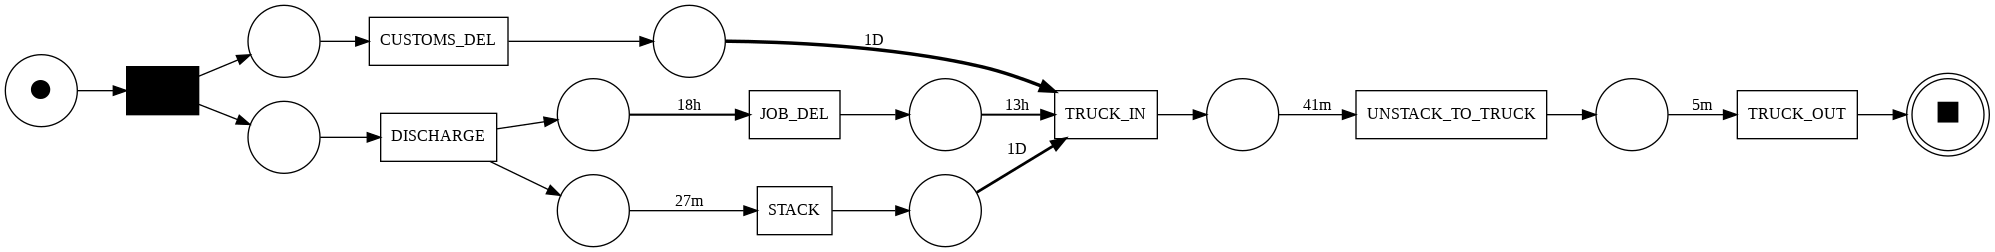

Petri net visualization displayed.
Inductive Miner model discovery and visualization complete for log_under_3_days.

--- Discovering model with Inductive Miner (noiseThreshold=0.0) ---


replaying log with TBR, completed traces ::   0%|          | 0/5 [00:00<?, ?it/s]

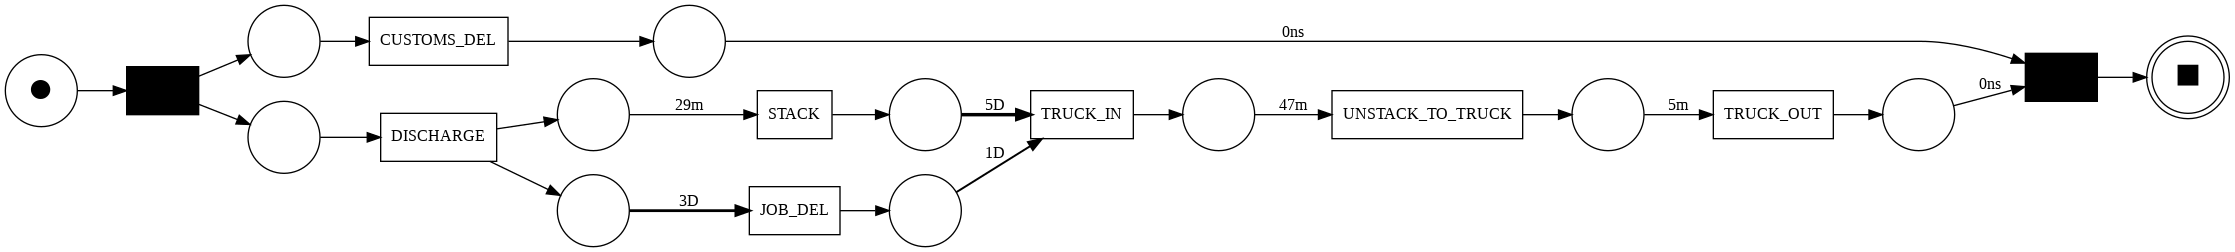

Petri net visualization displayed.
Inductive Miner model discovery and visualization complete for log_over_3_days.


In [ ]:
net_im_under_3_days, initial_marking_im_under_3_days, final_marking_im_under_3_days = perform_inductive_miner_with_eval_and_viz(log_under_3_days)
print("Inductive Miner model discovery and visualization complete for log_under_3_days.")

net_im_over_3_days, initial_marking_im_over_3_days, final_marking_im_over_3_days = perform_inductive_miner_with_eval_and_viz(log_over_3_days)
print("Inductive Miner model discovery and visualization complete for log_over_3_days.")

### Inductive Miner Models for Variants (Under 3 Days Log) ###

--- Variant 1 (Under 3 Days Log): CUSTOMS_DEL -> DISCHARGE -> STACK -> JOB_DEL -> TRUCK_IN -> UNSTACK_TO_TRUCK -> TRUCK_OUT (Frequency: 26568) ---

--- Discovering model with Inductive Miner (noiseThreshold=0.0) ---


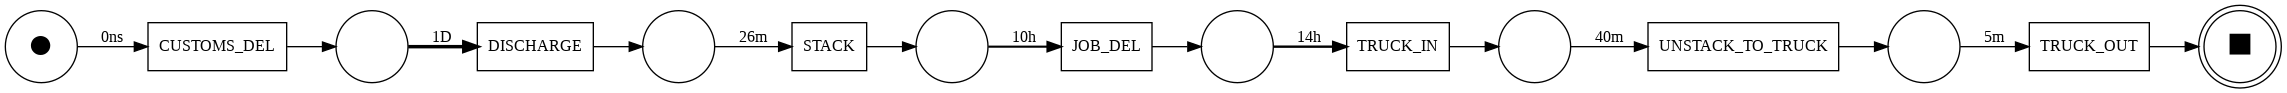

Petri net visualization displayed.

--- Variant 2 (Under 3 Days Log): DISCHARGE -> STACK -> CUSTOMS_DEL -> JOB_DEL -> TRUCK_IN -> UNSTACK_TO_TRUCK -> TRUCK_OUT (Frequency: 11745) ---

--- Discovering model with Inductive Miner (noiseThreshold=0.0) ---


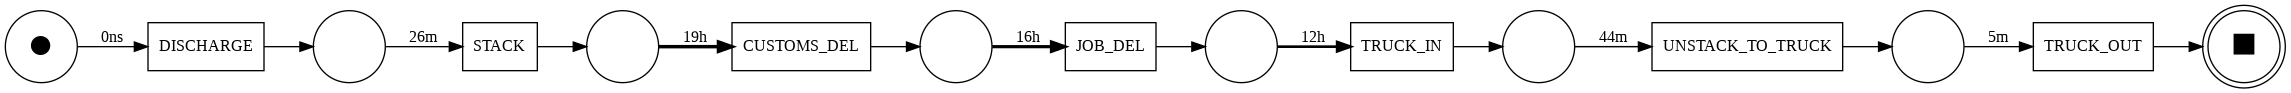

Petri net visualization displayed.

--- Variant 3 (Under 3 Days Log): CUSTOMS_DEL -> DISCHARGE -> JOB_DEL -> STACK -> TRUCK_IN -> UNSTACK_TO_TRUCK -> TRUCK_OUT (Frequency: 1361) ---

--- Discovering model with Inductive Miner (noiseThreshold=0.0) ---


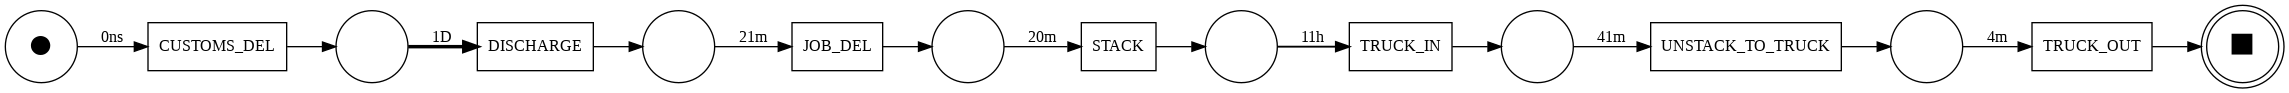

Petri net visualization displayed.

--- Variant 4 (Under 3 Days Log): DISCHARGE -> CUSTOMS_DEL -> STACK -> JOB_DEL -> TRUCK_IN -> UNSTACK_TO_TRUCK -> TRUCK_OUT (Frequency: 315) ---

--- Discovering model with Inductive Miner (noiseThreshold=0.0) ---


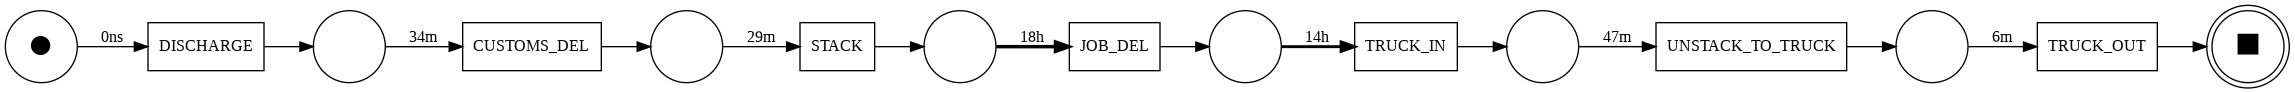

Petri net visualization displayed.

### Inductive Miner Models for Variants (Over 3 Days Log) ###

--- Variant 1 (Over 3 Days Log): DISCHARGE -> STACK -> CUSTOMS_DEL -> JOB_DEL -> TRUCK_IN -> UNSTACK_TO_TRUCK -> TRUCK_OUT (Frequency: 16500) ---

--- Discovering model with Inductive Miner (noiseThreshold=0.0) ---


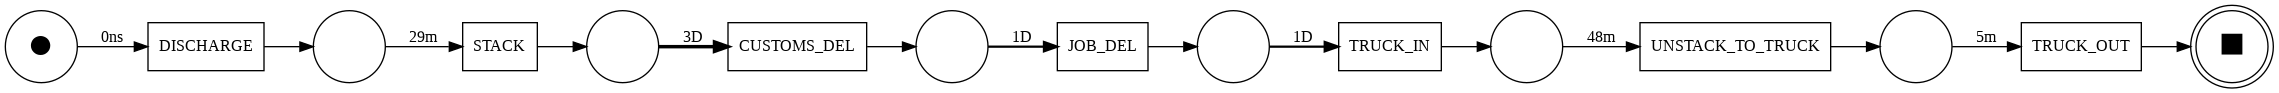

Petri net visualization displayed.

--- Variant 2 (Over 3 Days Log): CUSTOMS_DEL -> DISCHARGE -> STACK -> JOB_DEL -> TRUCK_IN -> UNSTACK_TO_TRUCK -> TRUCK_OUT (Frequency: 3364) ---

--- Discovering model with Inductive Miner (noiseThreshold=0.0) ---


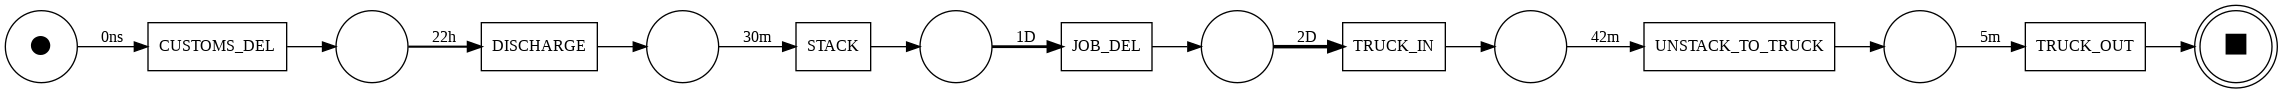

Petri net visualization displayed.

--- Variant 3 (Over 3 Days Log): DISCHARGE -> STACK -> JOB_DEL -> TRUCK_IN -> UNSTACK_TO_TRUCK -> TRUCK_OUT -> CUSTOMS_DEL (Frequency: 90) ---

--- Discovering model with Inductive Miner (noiseThreshold=0.0) ---


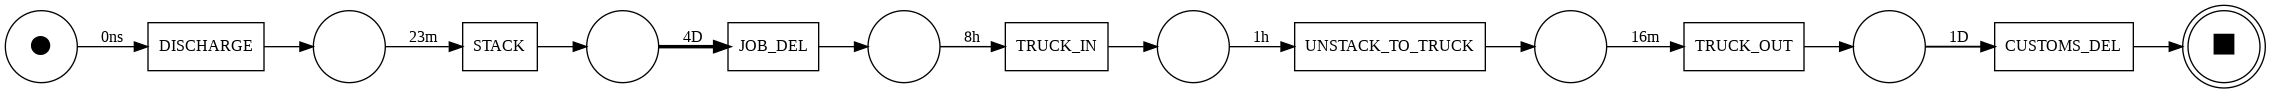

Petri net visualization displayed.

--- Variant 4 (Over 3 Days Log): DISCHARGE -> CUSTOMS_DEL -> STACK -> JOB_DEL -> TRUCK_IN -> UNSTACK_TO_TRUCK -> TRUCK_OUT (Frequency: 74) ---

--- Discovering model with Inductive Miner (noiseThreshold=0.0) ---


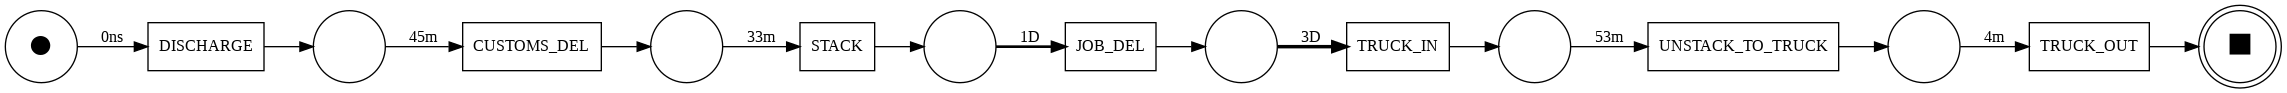

Petri net visualization displayed.

--- Variant 5 (Over 3 Days Log): CUSTOMS_DEL -> DISCHARGE -> JOB_DEL -> STACK -> TRUCK_IN -> UNSTACK_TO_TRUCK -> TRUCK_OUT (Frequency: 12) ---

--- Discovering model with Inductive Miner (noiseThreshold=0.0) ---


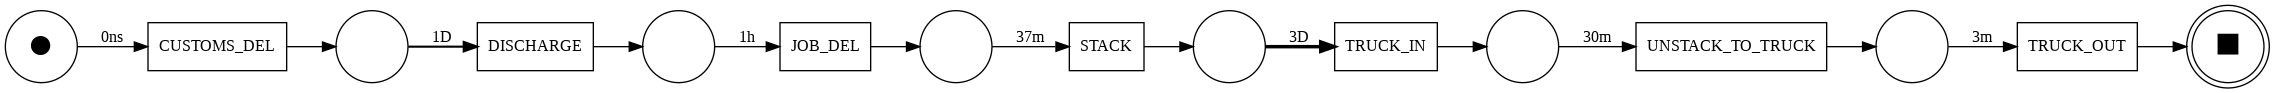

Petri net visualization displayed.


In [ ]:
from pm4py.objects.log.obj import EventLog

def get_variant_log(original_log, variant_tuple):
    """
    Filters an event log to include only traces belonging to a specific variant.
    """
    variant_log = EventLog()
    for trace in original_log:
        trace_variant = tuple([event['concept:name'] for event in trace])
        if trace_variant == variant_tuple:
            variant_log.append(trace)
    return variant_log

print("### Inductive Miner Models for Variants (Under 3 Days Log) ###")

# Variants for log_under_3_days
# Sorted by frequency, so index corresponds to variant 1, 2, 3, 4
sorted_variants_under_3_days = sorted(variants_under_3_days.items(), key=lambda item: len(item[1]), reverse=True)

for i, (variant_tuple, traces) in enumerate(sorted_variants_under_3_days):
    variant_name = ' -> '.join(variant_tuple)
    print(f"\n--- Variant {i+1} (Under 3 Days Log): {variant_name} (Frequency: {len(traces)}) ---")

    # Create a sub-log for this specific variant
    current_variant_log = get_variant_log(log_under_3_days, variant_tuple)

    if len(current_variant_log) > 0:
        net, im, fm = perform_inductive_miner_with_eval_and_viz(current_variant_log)
    else:
        print(f"No traces found for Variant {i+1} in log_under_3_days to display model.")

print("\n### Inductive Miner Models for Variants (Over 3 Days Log) ###")

# Variants for log_over_3_days
# Sorted by frequency, so index corresponds to variant 1, 2, 3, 4, 5
sorted_variants_over_3_days = sorted(variants_over_3_days.items(), key=lambda item: len(item[1]), reverse=True)

for i, (variant_tuple, traces) in enumerate(sorted_variants_over_3_days):
    variant_name = ' -> '.join(variant_tuple)
    print(f"\n--- Variant {i+1} (Over 3 Days Log): {variant_name} (Frequency: {len(traces)}) ---")

    # Create a sub-log for this specific variant
    current_variant_log = get_variant_log(log_over_3_days, variant_tuple)

    if len(current_variant_log) > 0:
        net, im, fm = perform_inductive_miner_with_eval_and_viz(current_variant_log)
    else:
        print(f"No traces found for Variant {i+1} in log_over_3_days to display model.")


## Heuristic Miner



--- Discovering model with Heuristic Miner (dependencyThreshold=0.2) ---


replaying log with TBR, completed traces ::   0%|          | 0/4 [00:00<?, ?it/s]

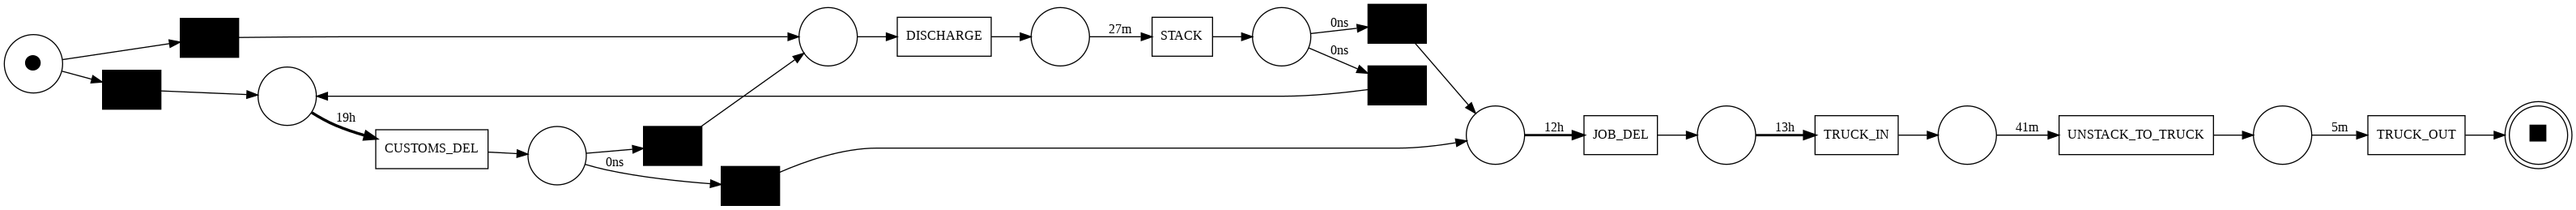

Petri net visualization displayed.
Heuristic Miner model discovery and visualization complete for log_under_3_days.


In [ ]:
net_hm_under_3_days, initial_marking_hm_under_3_days, final_marking_hm_under_3_days = perform_heuristic_miner_with_eval_and_viz(log_under_3_days)
print("Heuristic Miner model discovery and visualization complete for log_under_3_days.")

## Alpha Miner


--- Discovering model with Alpha Miner ---


replaying log with TBR, completed traces ::   0%|          | 0/4 [00:00<?, ?it/s]

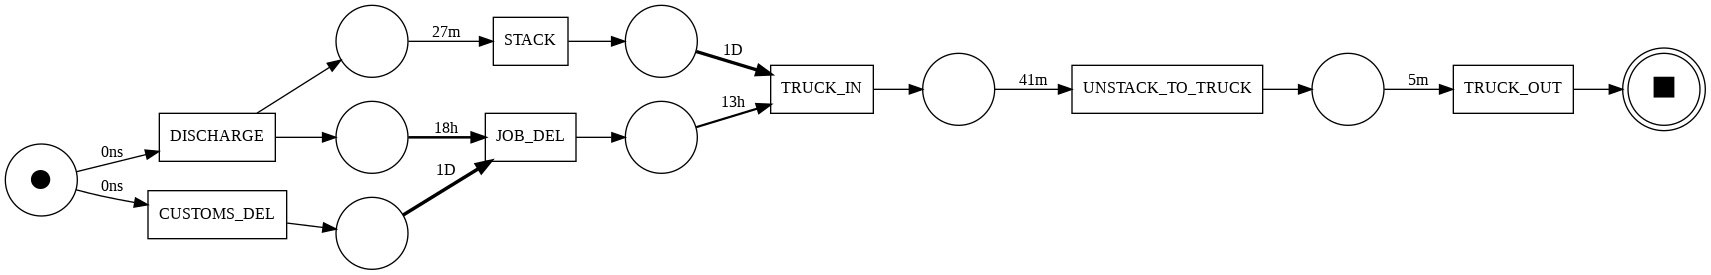

Petri net visualization displayed.
Alpha Miner model discovery and visualization complete for log_under_3_days.


In [ ]:
net_am_under_3_days, initial_marking_am_under_3_days, final_marking_am_under_3_days = perform_alpha_miner_with_eval_and_viz(log_under_3_days)
print("Alpha Miner model discovery and visualization complete for log_under_3_days.")

## Compare All Miner

### Log Under 3 Days


--- Starting Comparison of Process Discovery Algorithms ---

###########################################

Processing Inductive Miner...

--- Discovering model with Inductive Miner (noiseThreshold=0.0) ---


replaying log with TBR, completed traces ::   0%|          | 0/4 [00:00<?, ?it/s]

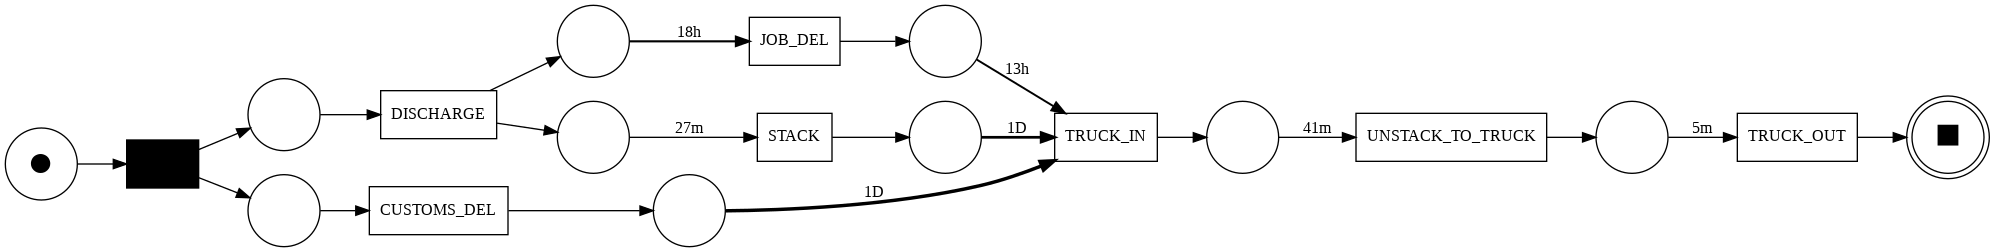

Petri net visualization displayed.


aligning log, completed variants ::   0%|          | 0/4 [00:00<?, ?it/s]

computing precision with alignments, completed variants ::   0%|          | 0/21 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/4 [00:00<?, ?it/s]

Input is ok.
Petri Net is a workflow net.
Every place is covered by s-components.
There are no dead tasks.
All tasks are live.
=== Model Evaluation ===
Fitness       : 1.0000
Precision     : 0.9372
Generalization: 0.9950
Simplicity    : 0.9048
Soundness     : True

###########################################

Processing Heuristic Miner...

--- Discovering model with Heuristic Miner (dependencyThreshold=0.2) ---


replaying log with TBR, completed traces ::   0%|          | 0/4 [00:00<?, ?it/s]

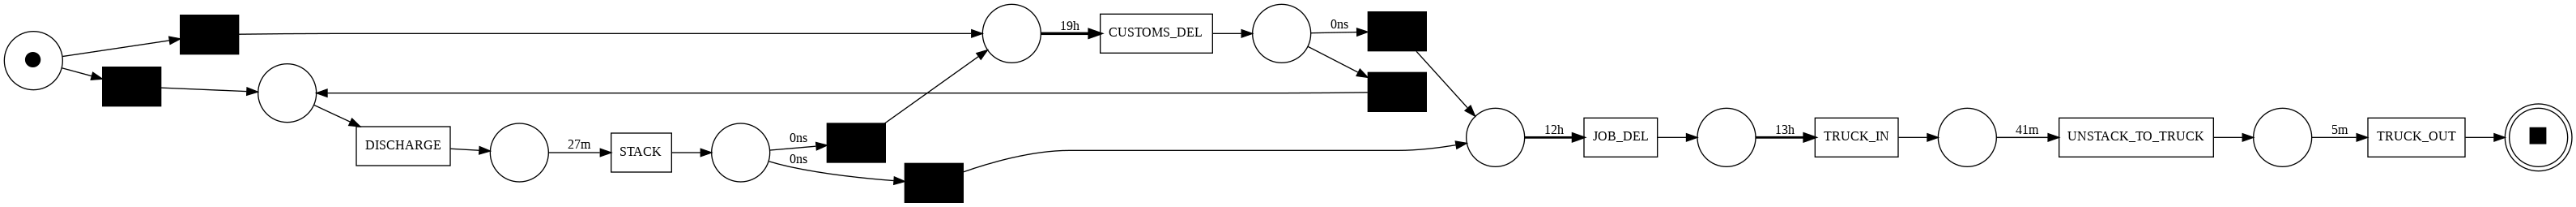

Petri net visualization displayed.


aligning log, completed variants ::   0%|          | 0/4 [00:00<?, ?it/s]

computing precision with alignments, completed variants ::   0%|          | 0/21 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/4 [00:00<?, ?it/s]

Input is ok.
Petri Net is a workflow net.
Every place is covered by s-components.
There are no dead tasks.
All tasks are live.
=== Model Evaluation ===
Fitness       : 0.9936
Precision     : 0.8005
Generalization: 0.9938
Simplicity    : 0.8571
Soundness     : True

###########################################

Processing Alpha Miner...

--- Discovering model with Alpha Miner ---


replaying log with TBR, completed traces ::   0%|          | 0/4 [00:00<?, ?it/s]

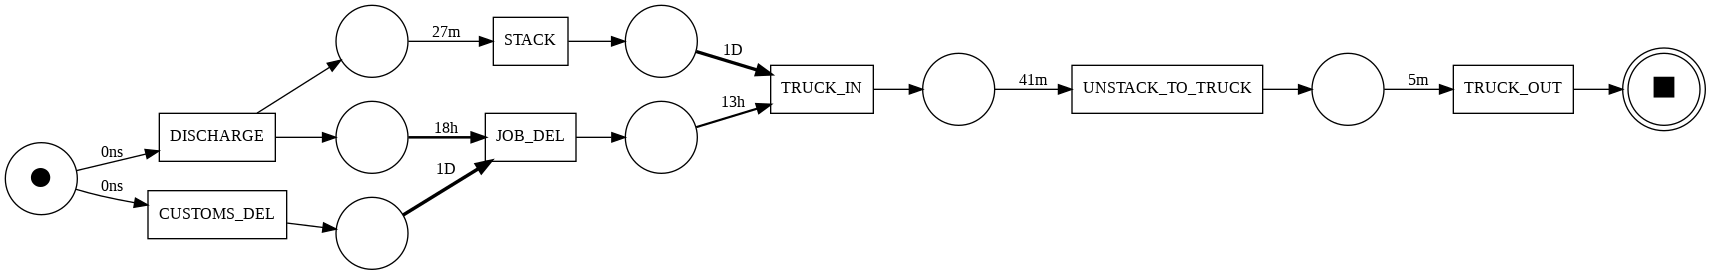

Petri net visualization displayed.


replaying log with TBR, completed traces ::   0%|          | 0/4 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/21 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/4 [00:00<?, ?it/s]

Input is ok.
Petri Net is a workflow net.
The following places are not covered by an s-component: [({'CUSTOMS_DEL'}, {'JOB_DEL'}), ({'DISCHARGE'}, {'JOB_DEL'}), ({'DISCHARGE'}, {'STACK'}), ({'JOB_DEL'}, {'TRUCK_IN'}), ({'STACK'}, {'TRUCK_IN'}), ({'TRUCK_IN'}, {'UNSTACK_TO_TRUCK'}), ({'UNSTACK_TO_TRUCK'}, {'TRUCK_OUT'}), end, start].
Not well-handled pairs are: [(23, 10), (23, 28)].
The following places are uncovered in uniform invariants: [({'CUSTOMS_DEL'}, {'JOB_DEL'}), ({'DISCHARGE'}, {'JOB_DEL'}), ({'DISCHARGE'}, {'STACK'}), ({'JOB_DEL'}, {'TRUCK_IN'}), ({'STACK'}, {'TRUCK_IN'}), ({'TRUCK_IN'}, {'UNSTACK_TO_TRUCK'}), ({'UNSTACK_TO_TRUCK'}, {'TRUCK_OUT'}), end, start]
The following places are uncovered in weighted invariants: [({'CUSTOMS_DEL'}, {'JOB_DEL'}), ({'DISCHARGE'}, {'JOB_DEL'}), ({'DISCHARGE'}, {'STACK'}), ({'JOB_DEL'}, {'TRUCK_IN'}), ({'STACK'}, {'TRUCK_IN'}), ({'TRUCK_IN'}, {'UNSTACK_TO_TRUCK'}), ({'UNSTACK_TO_TRUCK'}, {'TRUCK_OUT'}), end, start]
No improper conditions.
Th

In [ ]:
# Call the comparison function with log_under_3_days
comparison_df, im, hm, am = compare_all_miners(log_under_3_days)

In [ ]:
pm4py.write_pnml(im[0], im[1], im[2], "inductive_miner_under_3_days.pnml")
print("Inductive Miner model for log_under_3_days saved to 'inductive_miner_under_3_days.pnml'")

Inductive Miner model for log_under_3_days saved to 'inductive_miner_under_3_days.pnml'


### Log Over 3 Days


--- Starting Comparison of Process Discovery Algorithms ---

###########################################

Processing Inductive Miner...

--- Discovering model with Inductive Miner (noiseThreshold=0.0) ---


replaying log with TBR, completed traces ::   0%|          | 0/5 [00:00<?, ?it/s]

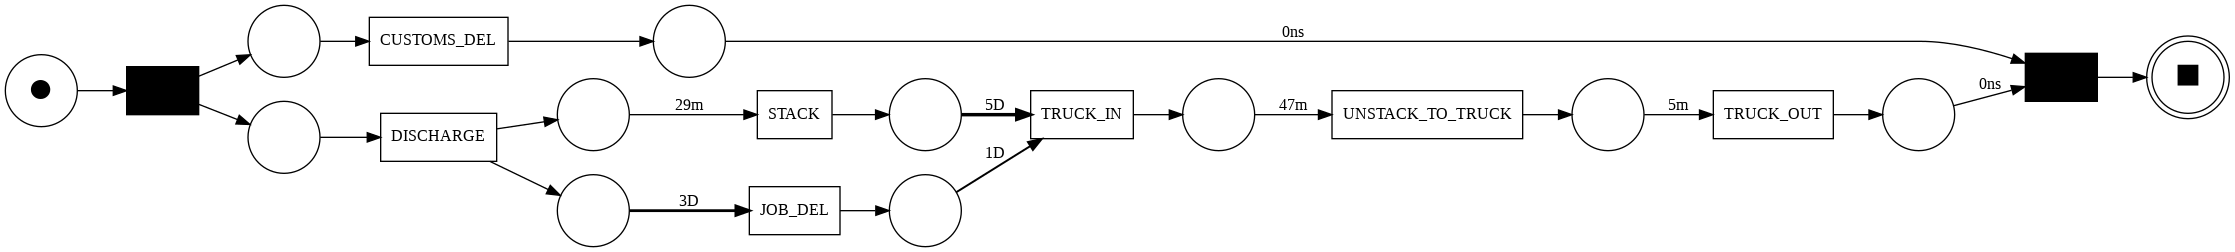

Petri net visualization displayed.


aligning log, completed variants ::   0%|          | 0/5 [00:00<?, ?it/s]

computing precision with alignments, completed variants ::   0%|          | 0/25 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/5 [00:00<?, ?it/s]

Input is ok.
Petri Net is a workflow net.
Every place is covered by s-components.
There are no dead tasks.
All tasks are live.
=== Model Evaluation ===
Fitness       : 1.0000
Precision     : 0.9205
Generalization: 0.9929
Simplicity    : 0.9130
Soundness     : True

###########################################

Processing Heuristic Miner...

--- Discovering model with Heuristic Miner (dependencyThreshold=0.2) ---


replaying log with TBR, completed traces ::   0%|          | 0/5 [00:00<?, ?it/s]

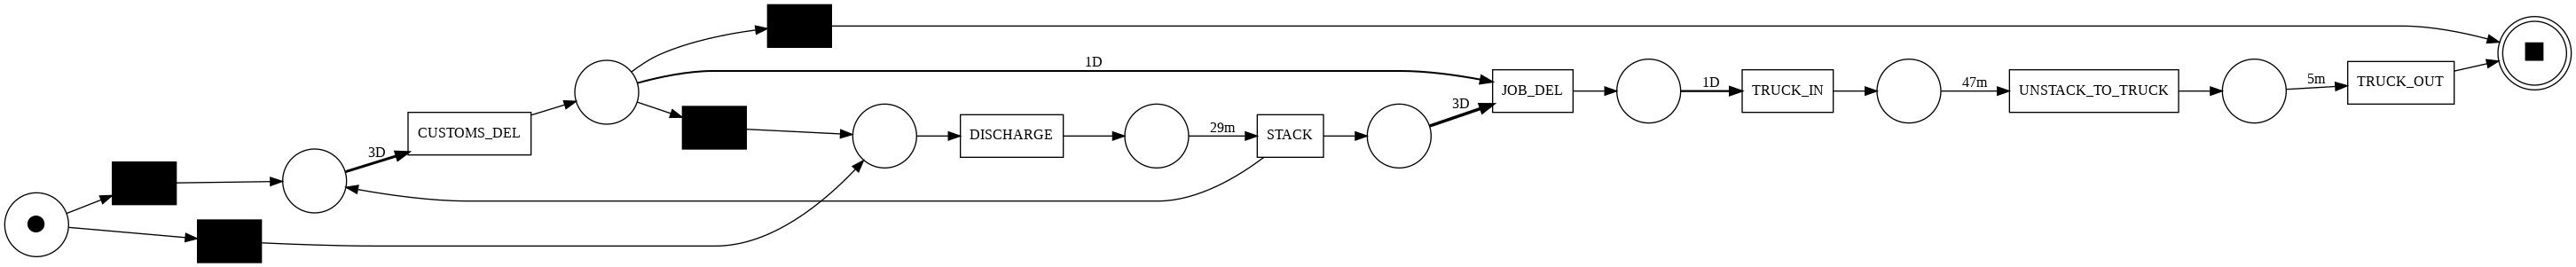

Petri net visualization displayed.


aligning log, completed variants ::   0%|          | 0/5 [00:00<?, ?it/s]

computing precision with alignments, completed variants ::   0%|          | 0/25 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/5 [00:00<?, ?it/s]

Input is ok.
Petri Net is a workflow net.
The following places are not covered by an s-component: [splace_in_JOB_DEL_STACK_0].
Not well-handled pairs are: [(15, 22), (15, 34), (15, 8), (37, 26), (33, 26)].
The following places are uncovered in uniform invariants: [splace_in_JOB_DEL_STACK_0]
The following places are uncovered in weighted invariants: [splace_in_JOB_DEL_STACK_0]
Improper WPD. The following are the improper conditions: [0, 10, 11, 12, 14, 15, 17, 19, 20].
The following sequences are unbounded: [[(hid_4, None)]]
=== Model Evaluation ===
Fitness       : 0.9767
Precision     : 0.8803
Generalization: 0.9008
Simplicity    : 0.7778
Soundness     : False

###########################################

Processing Alpha Miner...

--- Discovering model with Alpha Miner ---


replaying log with TBR, completed traces ::   0%|          | 0/5 [00:00<?, ?it/s]

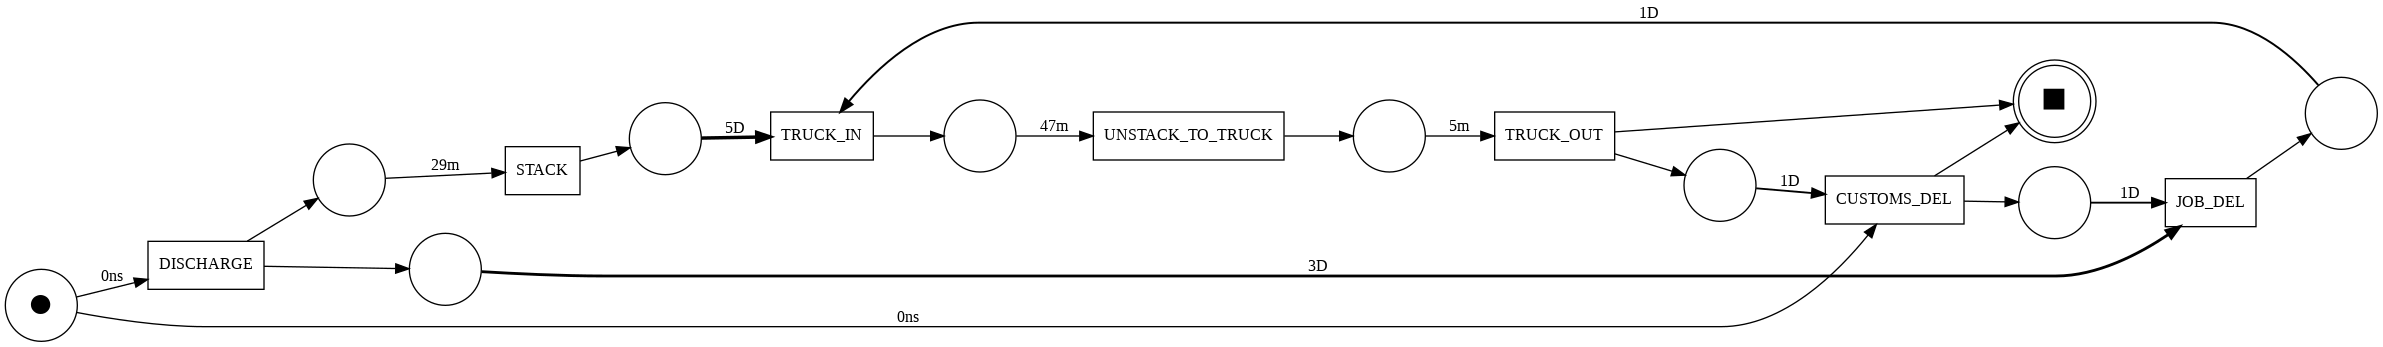

Petri net visualization displayed.


replaying log with TBR, completed traces ::   0%|          | 0/5 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/25 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/5 [00:00<?, ?it/s]

Input is ok.
Petri Net is a workflow net.
Every place is covered by s-components.
The following tasks are dead: [(CUSTOMS_DEL, 'CUSTOMS_DEL'), (JOB_DEL, 'JOB_DEL'), (TRUCK_IN, 'TRUCK_IN'), (TRUCK_OUT, 'TRUCK_OUT'), (UNSTACK_TO_TRUCK, 'UNSTACK_TO_TRUCK'), (short_circuited_transition, 'short_circuited_transition')]
=== Model Evaluation ===
Fitness       : 0.8182
Precision     : 1.0000
Generalization: 0.9929
Simplicity    : 0.7391
Soundness     : False

--- Overall Process Discovery Comparison Results ---
             Miner   fitness  precision  generalization  simplicity  soundness
0  Inductive Miner  0.999986   0.920508        0.992936    0.913043       True
1  Heuristic Miner  0.976732   0.880301        0.900762    0.777778      False
2      Alpha Miner  0.818182   1.000000        0.992936    0.739130      False


In [ ]:
# Call the comparison function with log_over_3_days
comparison_df, im, hm, am = compare_all_miners(log_over_3_days)

In [ ]:
pm4py.write_pnml(im[0], im[1], im[2], "inductive_miner_over_3_days.pnml")
print("Inductive Miner model for log_over_3_days saved to 'inductive_miner_over_3_days.pnml'")

Inductive Miner model for log_over_3_days saved to 'inductive_miner_over_3_days.pnml'


### All Logs


--- Starting Comparison of Process Discovery Algorithms ---

###########################################

Processing Inductive Miner...

--- Discovering model with Inductive Miner (noiseThreshold=0.0) ---


replaying log with TBR, completed traces ::   0%|          | 0/5 [00:00<?, ?it/s]

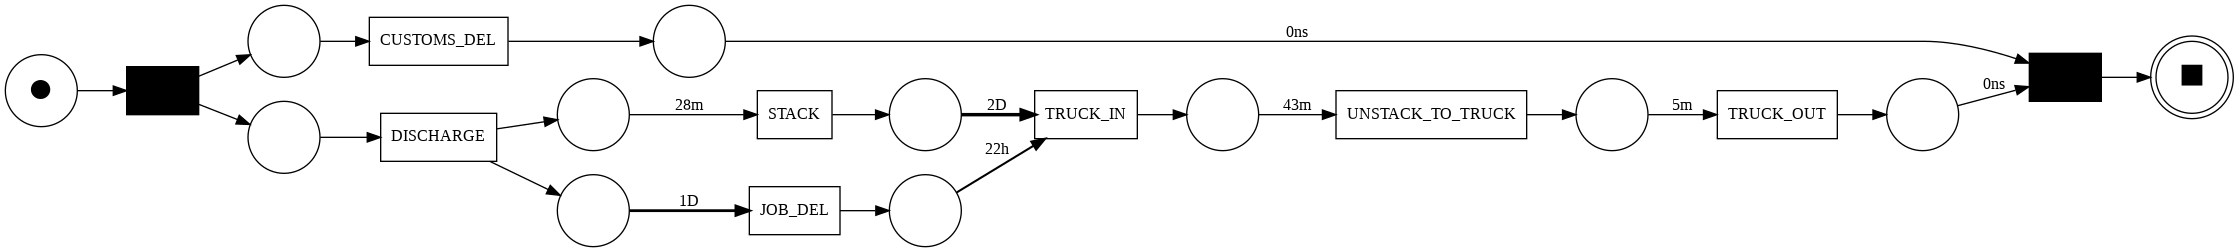

Petri net visualization displayed.


aligning log, completed variants ::   0%|          | 0/5 [00:00<?, ?it/s]

computing precision with alignments, completed variants ::   0%|          | 0/25 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/5 [00:00<?, ?it/s]

Input is ok.
Petri Net is a workflow net.
Every place is covered by s-components.
There are no dead tasks.
All tasks are live.
=== Model Evaluation ===
Fitness       : 1.0000
Precision     : 0.9509
Generalization: 0.9959
Simplicity    : 0.9130
Soundness     : True

###########################################

Processing Heuristic Miner...

--- Discovering model with Heuristic Miner (dependencyThreshold=0.2) ---


replaying log with TBR, completed traces ::   0%|          | 0/5 [00:00<?, ?it/s]

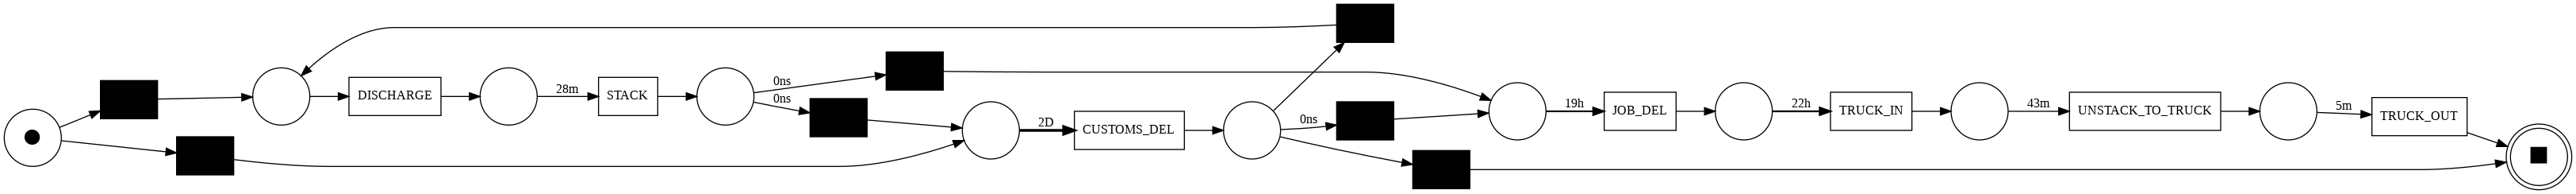

Petri net visualization displayed.


aligning log, completed variants ::   0%|          | 0/5 [00:00<?, ?it/s]

computing precision with alignments, completed variants ::   0%|          | 0/25 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/5 [00:00<?, ?it/s]

Input is ok.
Petri Net is a workflow net.
Every place is covered by s-components.
There are no dead tasks.
All tasks are live.
=== Model Evaluation ===
Fitness       : 0.9932
Precision     : 0.8485
Generalization: 0.9240
Simplicity    : 0.8065
Soundness     : True

###########################################

Processing Alpha Miner...

--- Discovering model with Alpha Miner ---


replaying log with TBR, completed traces ::   0%|          | 0/5 [00:00<?, ?it/s]

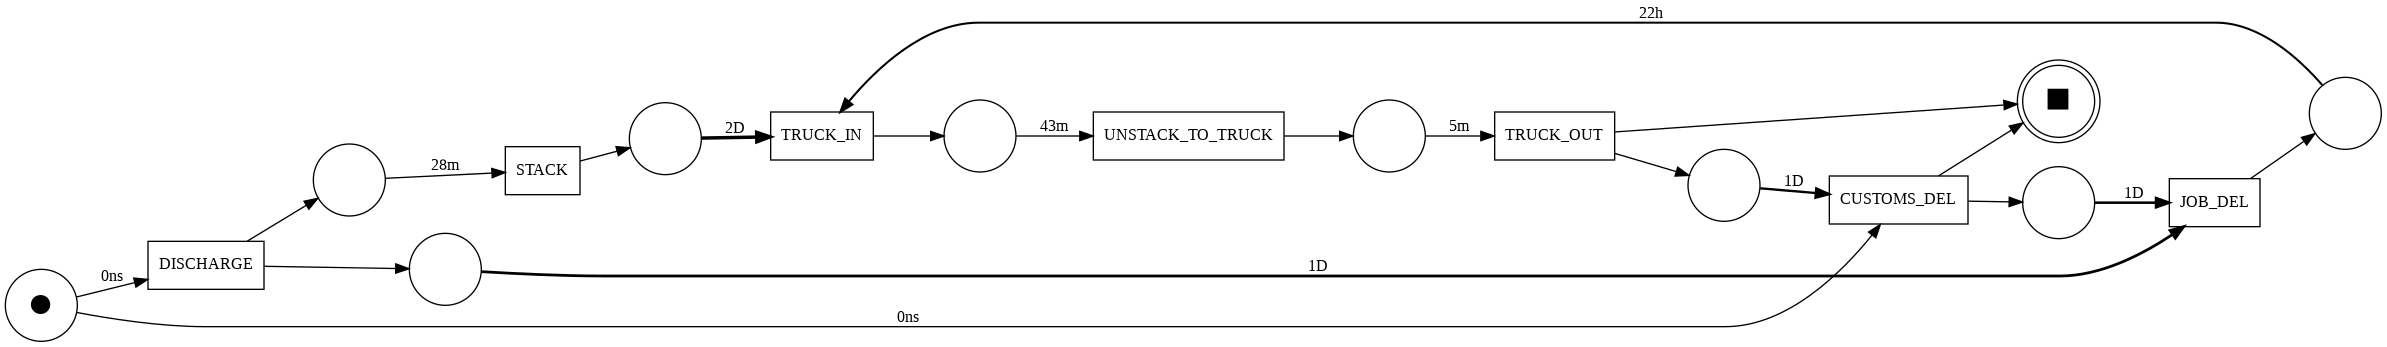

Petri net visualization displayed.


replaying log with TBR, completed traces ::   0%|          | 0/5 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/25 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/5 [00:00<?, ?it/s]

Input is ok.
Petri Net is a workflow net.
Every place is covered by s-components.
The following tasks are dead: [(CUSTOMS_DEL, 'CUSTOMS_DEL'), (JOB_DEL, 'JOB_DEL'), (TRUCK_IN, 'TRUCK_IN'), (TRUCK_OUT, 'TRUCK_OUT'), (UNSTACK_TO_TRUCK, 'UNSTACK_TO_TRUCK'), (short_circuited_transition, 'short_circuited_transition')]
=== Model Evaluation ===
Fitness       : 0.8182
Precision     : 1.0000
Generalization: 0.9959
Simplicity    : 0.7391
Soundness     : False

--- Overall Process Discovery Comparison Results ---
             Miner   fitness  precision  generalization  simplicity  soundness
0  Inductive Miner  0.999986   0.950863        0.995919    0.913043       True
1  Heuristic Miner  0.993248   0.848470        0.924042    0.806452       True
2      Alpha Miner  0.818182   1.000000        0.995919    0.739130      False


In [ ]:
# Call the comparison function with all logs
comparison_df, im, hm, am = compare_all_miners(event_log)

In [ ]:
pm4py.write_pnml(im[0], im[1], im[2], "inductive_miner_green_no_plp.pnml")
print("Inductive Miner model for inductive_miner_green_no_plp saved to 'inductive_miner_green_no_plp.pnml'")

Inductive Miner model for inductive_miner_green_no_plp saved to 'inductive_miner_green_no_plp.pnml'


### All Models from 3 Conditions


--- Displaying model: Best Model (under 3 days Log) ---


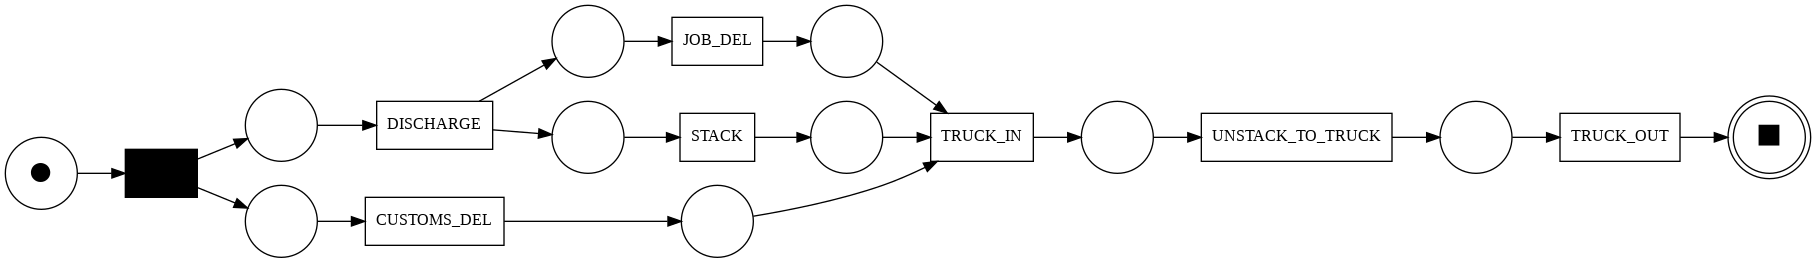

Petri net from 'inductive_miner_under_3_days.pnml' displayed.

--- Displaying model: Best Model (over 3 days Log) ---


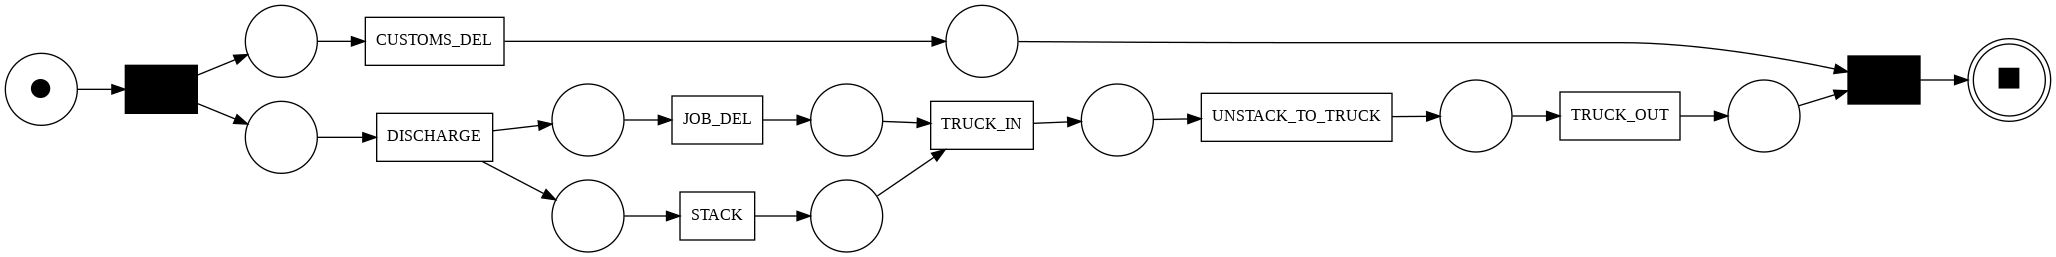

Petri net from 'inductive_miner_over_3_days.pnml' displayed.

--- Displaying model: Best Model (Original Log) ---


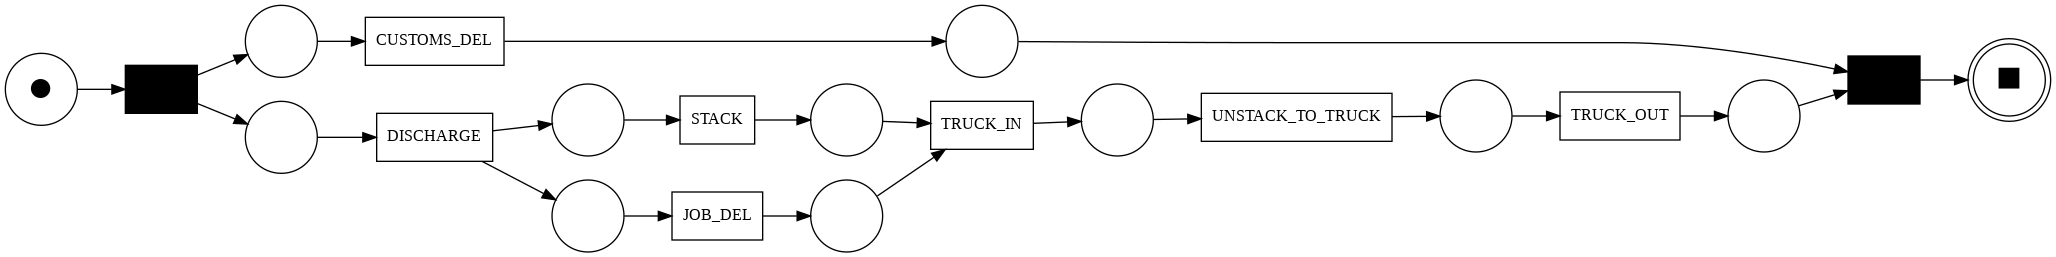

Petri net from 'inductive_miner_green_no_plp.pnml' displayed.


In [ ]:
# Display all requested PNML files
display_pnml_model('inductive_miner_under_3_days.pnml', 'Best Model (under 3 days Log)')
display_pnml_model('inductive_miner_over_3_days.pnml', 'Best Model (over 3 days Log)')
display_pnml_model('inductive_miner_green_no_plp.pnml', 'Best Model (Original Log)')

Overview SOP:
1. SOP utama mengacu pada Under 3 days Model yang menggambarkan case dengan durasi dwelling time memenuhi KPI, minim noise dan deviasi. CUSTOMES_DEL dapat selesai cepat.
2. Model Over 3 days Model menunjukkan bahwa aktivitas CUSTOMS_DEL menjadi bottle neck penyebab keterlambatan.
3. Model Original juga menunjukkan bahwa CUSTOMS DEL yang terlambat menjadi penyebab lama durasi dwelling time

Dalam konteks rekomendasi SOP, model yang diperoleh dari frequent behavior digunakan sebagai SOP inti karena merepresentasikan praktik normatif, sementara model dari infrequent behavior direkomendasikan sebagai SOP pengecualian yang perlu diakomodir dalam kondisi khusus. Sedangkan model dari log lengkap berperan sebagai referensi komprehensif misalnya untuk keperluan pelatihan, audit, dan evaluasi proses.

Temuan penting:

Analisis terhadap aktivitas “check credit” menunjukkan bahwa menurut SOP utama (frequent log) aktivitas ini harus dilakukan sebelum calculate capacity dan check system.



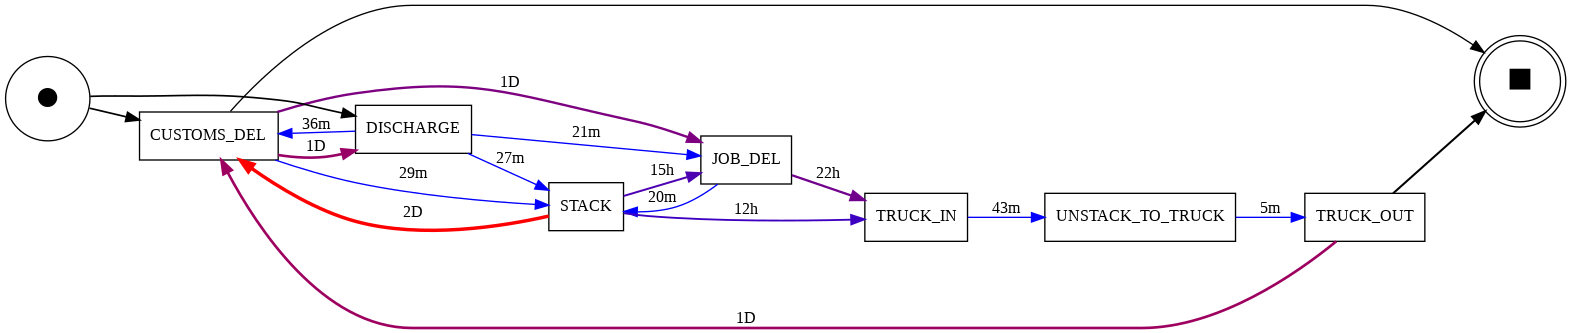

In [ ]:
import pm4py

# Pastikan log Anda punya kolom 'time:timestamp' (waktu selesai)
# dan idealnya 'start_timestamp' (jika ada)

# Menghasilkan DFG (Directly-Follows Graph) dengan metrik waktu
performance_dfg = pm4py.discover_performance_dfg(event_log)

# Menampilkan visualisasi dengan rata-rata waktu (bisa juga diubah ke Petri Net)
pm4py.view_performance_dfg(performance_dfg[0], performance_dfg[1], performance_dfg[2])

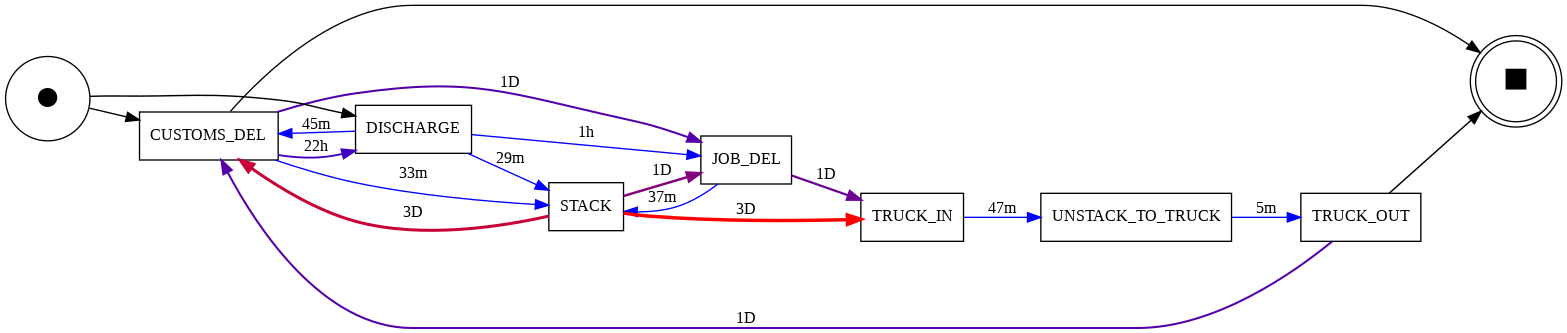

In [ ]:
import pm4py

# Pastikan log Anda punya kolom 'time:timestamp' (waktu selesai)
# dan idealnya 'start_timestamp' (jika ada)

# Menghasilkan DFG (Directly-Follows Graph) dengan metrik waktu
performance_dfg = pm4py.discover_performance_dfg(log_over_3_days)

# Menampilkan visualisasi dengan rata-rata waktu (bisa juga diubah ke Petri Net)
pm4py.view_performance_dfg(performance_dfg[0], performance_dfg[1], performance_dfg[2])

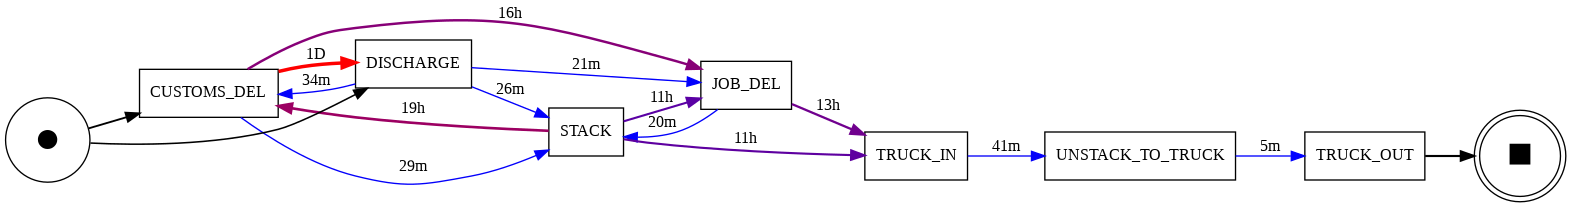

In [ ]:
import pm4py

# Pastikan log Anda punya kolom 'time:timestamp' (waktu selesai)
# dan idealnya 'start_timestamp' (jika ada)

# Menghasilkan DFG (Directly-Follows Graph) dengan metrik waktu
performance_dfg = pm4py.discover_performance_dfg(log_under_3_days)

# Menampilkan visualisasi dengan rata-rata waktu (bisa juga diubah ke Petri Net)
pm4py.view_performance_dfg(performance_dfg[0], performance_dfg[1], performance_dfg[2])